## 1. Setup & Installation

In [1]:
# Install required libraries (most are pre-installed in Colab)
!pip install -q datasets transformers torch

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from collections import Counter
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Mount Google Drive (Optional)

Mount Google Drive to save analysis results and visualizations.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Create project directory in Google Drive
!mkdir -p "/content/drive/MyDrive/Claussifier"
!mkdir -p "/content/drive/MyDrive/Claussifier/models"
!mkdir -p "/content/drive/MyDrive/Claussifier/results"
!mkdir -p "/content/drive/MyDrive/Claussifier/visualizations"

print("✓ Google Drive mounted and directories created!")

Mounted at /content/drive
✓ Google Drive mounted and directories created!


## 3. Load Dataset

Load the LexGLUE unfair_tos dataset directly from Hugging Face (no download needed!).

In [4]:
# Load dataset - streams directly from Hugging Face
print("Loading LexGLUE unfair_tos dataset...")
dataset = load_dataset("lex_glue", "unfair_tos")

print("\n✓ Dataset loaded successfully!")
print(f"\nDataset splits:")
print(f"  - Train: {len(dataset['train'])} examples")
print(f"  - Validation: {len(dataset['validation'])} examples")
print(f"  - Test: {len(dataset['test'])} examples")
print(f"  - Total: {len(dataset['train']) + len(dataset['validation']) + len(dataset['test'])} examples")

Loading LexGLUE unfair_tos dataset...


README.md: 0.00B [00:00, ?B/s]

unfair_tos/train-00000-of-00001.parquet:   0%|          | 0.00/501k [00:00<?, ?B/s]

unfair_tos/test-00000-of-00001.parquet:   0%|          | 0.00/147k [00:00<?, ?B/s]

unfair_tos/validation-00000-of-00001.par(…):   0%|          | 0.00/218k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5532 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1607 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2275 [00:00<?, ? examples/s]


✓ Dataset loaded successfully!

Dataset splits:
  - Train: 5532 examples
  - Validation: 2275 examples
  - Test: 1607 examples
  - Total: 9414 examples


## 4. Explore Dataset Structure

In [5]:
# Examine dataset features
print("Dataset Features:")
print(dataset['train'].features)

print("\n" + "="*80)
print("\nLabel Names (Risk Categories):")
label_names = dataset['train'].features['labels'].feature.names
for i, label in enumerate(label_names):
    print(f"  {i}: {label}")

Dataset Features:
{'text': Value('string'), 'labels': List(ClassLabel(names=['Limitation of liability', 'Unilateral termination', 'Unilateral change', 'Content removal', 'Contract by using', 'Choice of law', 'Jurisdiction', 'Arbitration']))}


Label Names (Risk Categories):
  0: Limitation of liability
  1: Unilateral termination
  2: Unilateral change
  3: Content removal
  4: Contract by using
  5: Choice of law
  6: Jurisdiction
  7: Arbitration


In [6]:
# View sample examples
print("Sample Examples from Training Set:\n")
print("="*80)

for i in range(3):
    example = dataset['train'][i]
    print(f"\nExample {i+1}:")
    print(f"Text: {example['text'][:200]}...")
    print(f"Labels (indices): {example['labels']}")
    print(f"Labels (names): {[label_names[idx] for idx in example['labels']]}")
    print("-"*80)

Sample Examples from Training Set:


Example 1:
Text: notice to california subscribers : you may cancel your subscription , without penalty or obligation , at any time prior to midnight of the third business day following the date you subscribed . 
...
Labels (indices): []
Labels (names): []
--------------------------------------------------------------------------------

Example 2:
Text: if you subscribed using your apple id , refunds are handled by apple , not tinder . 
...
Labels (indices): []
Labels (names): []
--------------------------------------------------------------------------------

Example 3:
Text: if you wish to request a refund , please visit https://getsupport.apple.com . 
...
Labels (indices): []
Labels (names): []
--------------------------------------------------------------------------------


## 5. Convert to Pandas for Analysis

In [7]:
# Convert to pandas DataFrames
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

print("Training set shape:", train_df.shape)
print("\nFirst few rows:")
train_df.head()

Training set shape: (5532, 2)

First few rows:


,text,labels
0,notice to california subscribers : you may can...,[]
1,"if you subscribed using your apple id , refund...",[]
2,"if you wish to request a refund , please visit...",[]
3,if you subscribed using your google play store...,[]
4,key changes in this version : we 've included ...,[]


## 6. Label Distribution Analysis

In [8]:
# Count occurrences of each label
def count_labels(df):
    """Count occurrences of each label in the dataset."""
    label_counts = Counter()
    for labels in df['labels']:
        label_counts.update(labels)
    return label_counts

train_label_counts = count_labels(train_df)
val_label_counts = count_labels(val_df)
test_label_counts = count_labels(test_df)

# Create summary DataFrame
label_summary = pd.DataFrame({
    'Label': label_names,
    'Train': [train_label_counts[i] for i in range(len(label_names))],
    'Val': [val_label_counts[i] for i in range(len(label_names))],
    'Test': [test_label_counts[i] for i in range(len(label_names))]
})

label_summary['Total'] = label_summary['Train'] + label_summary['Val'] + label_summary['Test']
label_summary['Train %'] = (label_summary['Train'] / len(train_df) * 100).round(2)

print("Label Distribution Across Splits:\n")
print(label_summary.to_string(index=False))

Label Distribution Across Splits:

                  Label  Train  Val  Test  Total  Train %
Limitation of liability    191   67    38    296     3.45
 Unilateral termination    139   59    38    236     2.51
      Unilateral change    122   28    38    188     2.21
        Content removal     73   32    13    118     1.32
      Contract by using     76   18    23    117     1.37
          Choice of law     39   18    13     70     0.70
           Jurisdiction     34   18    16     68     0.61
            Arbitration     28    9     7     44     0.51


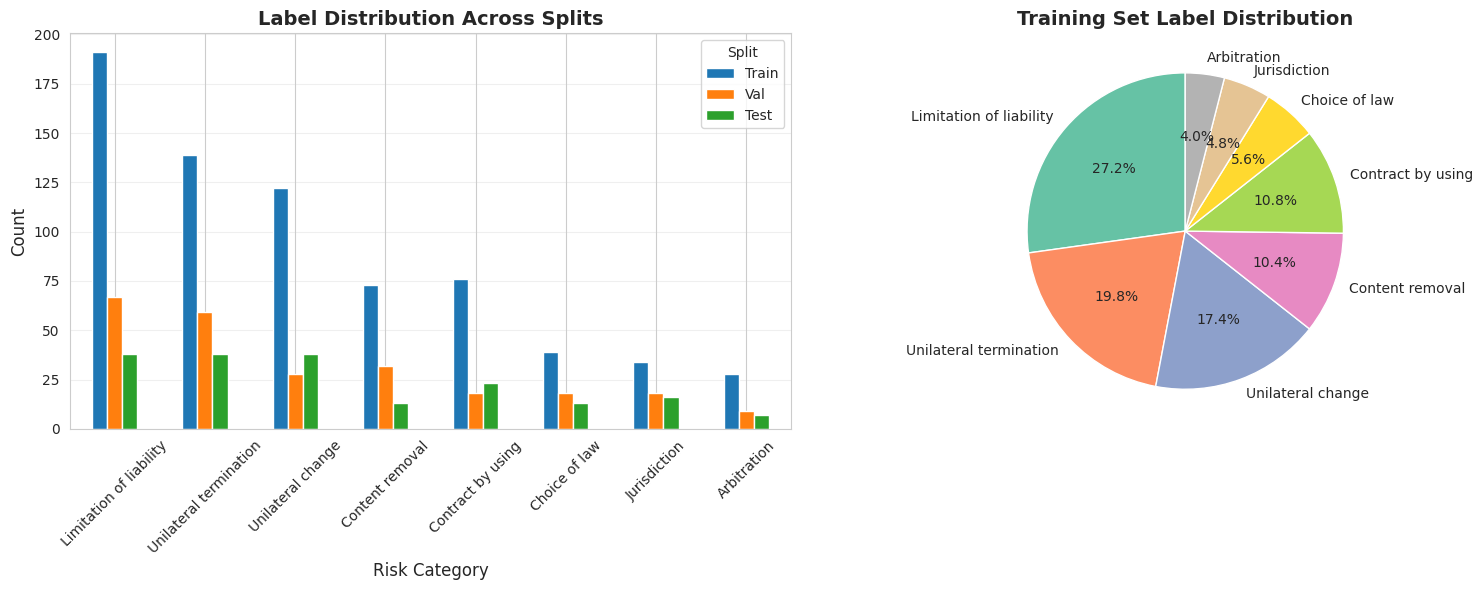


✓ Visualization saved to Google Drive!


In [9]:
# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
ax1 = axes[0]
label_summary.plot(x='Label', y=['Train', 'Val', 'Test'], kind='bar', ax=ax1, rot=45)
ax1.set_title('Label Distribution Across Splits', fontsize=14, fontweight='bold')
ax1.set_xlabel('Risk Category', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.legend(title='Split')
ax1.grid(axis='y', alpha=0.3)

# Pie chart for training set
ax2 = axes[1]
colors = sns.color_palette('Set2', len(label_names))
ax2.pie(label_summary['Train'], labels=label_summary['Label'], autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('Training Set Label Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Claussifier/visualizations/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to Google Drive!")

## 7. Class Imbalance Analysis

In [10]:
# Calculate class imbalance ratio
max_count = label_summary['Train'].max()
min_count = label_summary['Train'].min()
imbalance_ratio = max_count / min_count

print(f"Class Imbalance Analysis:")
print(f"  - Most common label: {label_summary.loc[label_summary['Train'].idxmax(), 'Label']} ({max_count} examples)")
print(f"  - Least common label: {label_summary.loc[label_summary['Train'].idxmin(), 'Label']} ({min_count} examples)")
print(f"  - Imbalance ratio: {imbalance_ratio:.2f}x")
print(f"\n⚠️ Recommendation: Use class-weighted loss function to handle imbalance!")

Class Imbalance Analysis:
  - Most common label: Limitation of liability (191 examples)
  - Least common label: Arbitration (28 examples)
  - Imbalance ratio: 6.82x

⚠️ Recommendation: Use class-weighted loss function to handle imbalance!


## 8. Clause Length Analysis

In [11]:
# Calculate clause lengths (in words and characters)
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))
train_df['char_count'] = train_df['text'].apply(len)

print("Clause Length Statistics (Training Set):\n")
print("Word Count:")
print(train_df['word_count'].describe())
print("\nCharacter Count:")
print(train_df['char_count'].describe())

Clause Length Statistics (Training Set):

Word Count:
count    5532.000000
mean       32.283080
std        24.745549
min         6.000000
25%        17.000000
50%        26.000000
75%        39.000000
max       441.000000
Name: word_count, dtype: float64

Character Count:
count    5532.000000
mean      179.276211
std       134.765833
min        15.000000
25%        96.000000
50%       147.000000
75%       221.000000
max      2535.000000
Name: char_count, dtype: float64


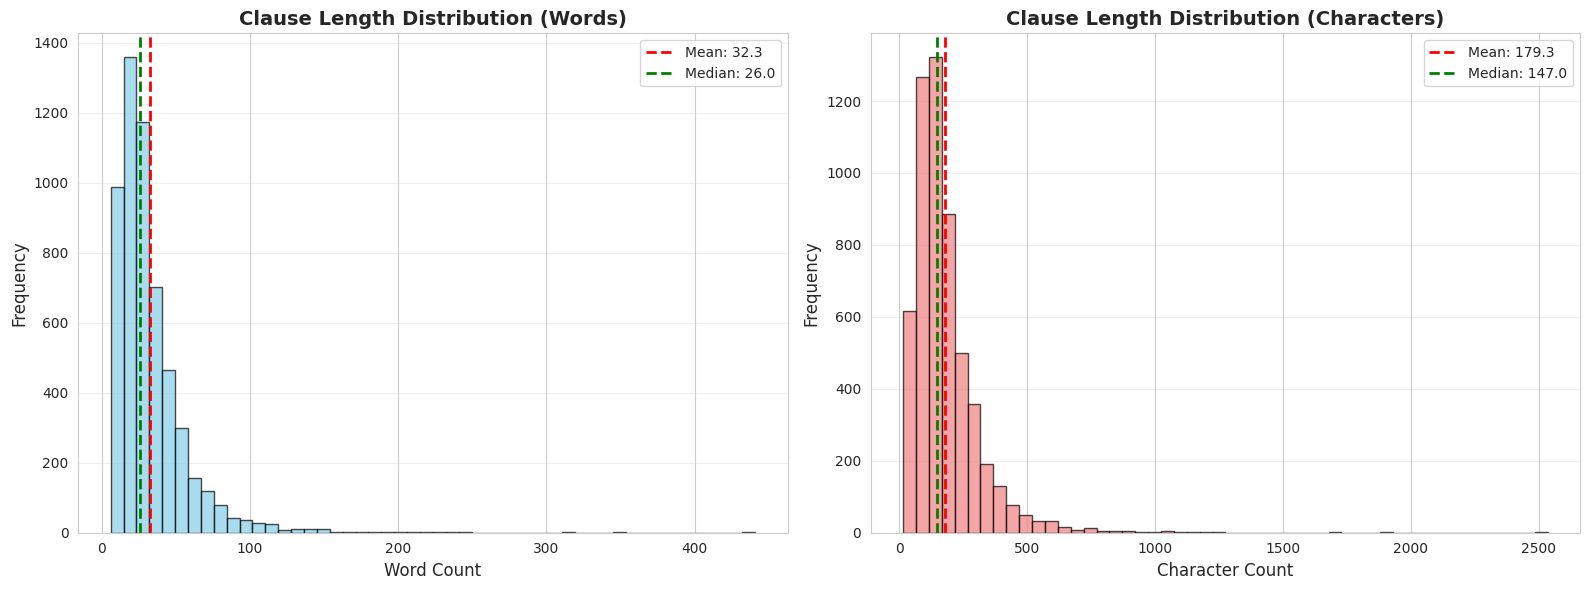


✓ Visualization saved to Google Drive!


In [12]:
# Visualize clause length distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word count distribution
ax1 = axes[0]
ax1.hist(train_df['word_count'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(train_df['word_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train_df["word_count"].mean():.1f}')
ax1.axvline(train_df['word_count'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {train_df["word_count"].median():.1f}')
ax1.set_title('Clause Length Distribution (Words)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Word Count', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Character count distribution
ax2 = axes[1]
ax2.hist(train_df['char_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax2.axvline(train_df['char_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {train_df["char_count"].mean():.1f}')
ax2.axvline(train_df['char_count'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {train_df["char_count"].median():.1f}')
ax2.set_title('Clause Length Distribution (Characters)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Character Count', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Claussifier/visualizations/clause_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to Google Drive!")

In [13]:
# Check how many clauses exceed BERT's max length (512 tokens)
# Rough estimate: 1 token ≈ 0.75 words
estimated_token_count = train_df['word_count'] / 0.75
exceeds_512 = (estimated_token_count > 512).sum()
percentage = (exceeds_512 / len(train_df)) * 100

print(f"\nBERT Token Length Analysis:")
print(f"  - Clauses likely exceeding 512 tokens: {exceeds_512} ({percentage:.2f}%)")
print(f"  - These will be truncated during tokenization")
print(f"\n✓ Recommendation: Use truncation strategy 'longest_first' to keep most important content")


BERT Token Length Analysis:
  - Clauses likely exceeding 512 tokens: 1 (0.02%)
  - These will be truncated during tokenization

✓ Recommendation: Use truncation strategy 'longest_first' to keep most important content


## 9. Multi-Label Analysis

In [14]:
# Analyze how many labels each clause has
train_df['num_labels'] = train_df['labels'].apply(len)

print("Multi-Label Statistics:\n")
print(train_df['num_labels'].value_counts().sort_index())

print(f"\nAverage labels per clause: {train_df['num_labels'].mean():.2f}")
print(f"Max labels in a single clause: {train_df['num_labels'].max()}")
print(f"Clauses with no labels: {(train_df['num_labels'] == 0).sum()}")
print(f"Clauses with multiple labels: {(train_df['num_labels'] > 1).sum()} ({(train_df['num_labels'] > 1).sum() / len(train_df) * 100:.2f}%)")

Multi-Label Statistics:

num_labels
0    4902
1     567
2      54
3       9
Name: count, dtype: int64

Average labels per clause: 0.13
Max labels in a single clause: 3
Clauses with no labels: 4902
Clauses with multiple labels: 63 (1.14%)


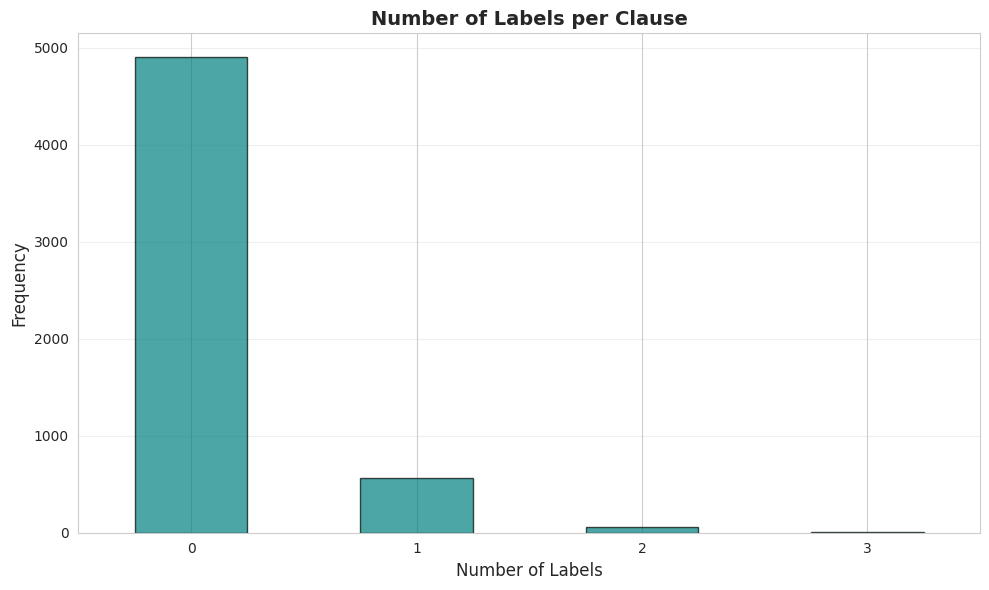


✓ Visualization saved to Google Drive!


In [15]:
# Visualize number of labels per clause
plt.figure(figsize=(10, 6))
train_df['num_labels'].value_counts().sort_index().plot(kind='bar', color='teal', edgecolor='black', alpha=0.7)
plt.title('Number of Labels per Clause', fontsize=14, fontweight='bold')
plt.xlabel('Number of Labels', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Claussifier/visualizations/multi_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to Google Drive!")

## 10. Label Co-occurrence Analysis

In [16]:
# Create co-occurrence matrix
num_labels = len(label_names)
cooccurrence_matrix = np.zeros((num_labels, num_labels))

for labels in train_df['labels']:
    for i in labels:
        for j in labels:
            cooccurrence_matrix[i][j] += 1

# Convert to DataFrame for better visualization
cooccurrence_df = pd.DataFrame(
    cooccurrence_matrix,
    index=label_names,
    columns=label_names
)

print("Label Co-occurrence Matrix:\n")
print(cooccurrence_df.astype(int))

Label Co-occurrence Matrix:

                         Limitation of liability  Unilateral termination  \
Limitation of liability                      191                       9   
Unilateral termination                         9                     139   
Unilateral change                              8                      22   
Content removal                                4                      24   
Contract by using                              0                       0   
Choice of law                                  0                       0   
Jurisdiction                                   0                       0   
Arbitration                                    0                       0   

                         Unilateral change  Content removal  \
Limitation of liability                  8                4   
Unilateral termination                  22               24   
Unilateral change                      122                6   
Content removal                   

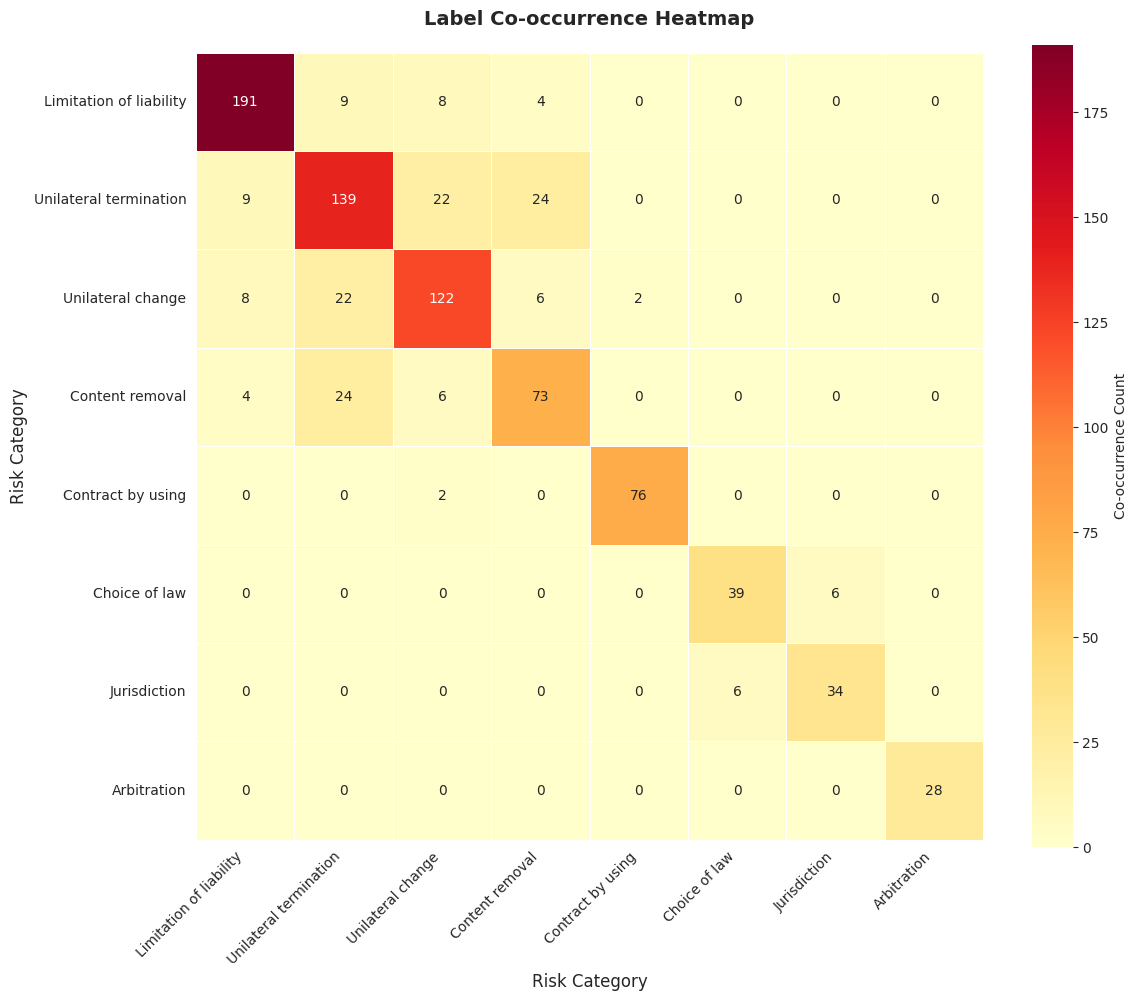


✓ Visualization saved to Google Drive!


In [17]:
# Visualize co-occurrence matrix as heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence_df, annot=True, fmt='.0f', cmap='YlOrRd',
            square=True, linewidths=0.5, cbar_kws={'label': 'Co-occurrence Count'})
plt.title('Label Co-occurrence Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Risk Category', fontsize=12)
plt.ylabel('Risk Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Claussifier/visualizations/label_cooccurrence_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to Google Drive!")

## 11. Summary Report

In [20]:
# Generate comprehensive summary report
summary_report = f"""
{'='*80}
CLAUSSIFIER - EXPLORATORY DATA ANALYSIS SUMMARY REPORT
{'='*80}

DATASET: LexGLUE unfair_tos
DATE: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*80}
1. DATASET SIZE
{'='*80}
  - Training set:   {len(train_df):,} examples
  - Validation set: {len(val_df):,} examples
  - Test set:       {len(test_df):,} examples
  - Total:          {len(train_df) + len(val_df) + len(test_df):,} examples

{'='*80}
2. RISK CATEGORIES (8 total)
{'='*80}
"""

for i, label in enumerate(label_names):
    count = label_summary.loc[i, 'Train']
    percentage = label_summary.loc[i, 'Train %']
    summary_report += f"  {i+1}. {label:30s} - {count:4d} examples ({percentage:5.2f}%)\n"

summary_report += f"""
{'='*80}
3. CLASS IMBALANCE
{'='*80}
  - Most common:    {label_summary.loc[label_summary['Train'].idxmax(), 'Label']} ({max_count} examples)
  - Least common:   {label_summary.loc[label_summary['Train'].idxmin(), 'Label']} ({min_count} examples)
  - Imbalance ratio: {imbalance_ratio:.2f}x
  - Recommendation: Use class-weighted loss function

{'='*80}
4. CLAUSE LENGTH STATISTICS
{'='*80}
  Word Count:
    - Mean:   {train_df['word_count'].mean():.1f} words
    - Median: {train_df['word_count'].median():.1f} words
    - Min:    {train_df['word_count'].min()} words
    - Max:    {train_df['word_count'].max()} words
    - Std:    {train_df['word_count'].std():.1f} words

  Character Count:
    - Mean:   {train_df['char_count'].mean():.1f} characters
    - Median: {train_df['char_count'].median():.1f} characters
    - Min:    {train_df['char_count'].min()} characters
    - Max:    {train_df['char_count'].max()} characters

  BERT Token Limit (512 tokens):
    - Clauses likely exceeding limit: {exceeds_512} ({percentage:.2f}%)
    - Recommendation: Use truncation='longest_first'

{'='*80}
5. MULTI-LABEL ANALYSIS
{'='*80}
  - Average labels per clause: {train_df['num_labels'].mean():.2f}
  - Max labels in single clause: {train_df['num_labels'].max()}
  - Clauses with no labels: {(train_df['num_labels'] == 0).sum()}
  - Clauses with multiple labels: {(train_df['num_labels'] > 1).sum()} ({(train_df['num_labels'] > 1).sum() / len(train_df) * 100:.2f}%)

{'='*80}
6. KEY INSIGHTS & RECOMMENDATIONS
{'='*80}
  ✓ Dataset is well-balanced across train/val/test splits
  ✓ Moderate class imbalance - use weighted loss function
  ✓ Most clauses are within BERT's token limit
  ✓ Multi-label classification is appropriate (~{(train_df['num_labels'] > 1).sum() / len(train_df) * 100:.1f}% have multiple labels)
  ✓ Ready to proceed to preprocessing and model training

{'='*80}
END OF REPORT
{'='*80}
"""

print(summary_report)

# Save report to Google Drive
with open('/content/drive/MyDrive/Claussifier/results/eda_summary_report.txt', 'w') as f:
    f.write(summary_report)

print("\n✓ Summary report saved to Google Drive!")


CLAUSSIFIER - EXPLORATORY DATA ANALYSIS SUMMARY REPORT

DATASET: LexGLUE unfair_tos
DATE: 2026-01-31 20:01:45

1. DATASET SIZE
  - Training set:   5,532 examples
  - Validation set: 2,275 examples
  - Test set:       1,607 examples
  - Total:          9,414 examples

2. RISK CATEGORIES (8 total)
  1. Limitation of liability        -  191 examples ( 3.45%)
  2. Unilateral termination         -  139 examples ( 2.51%)
  3. Unilateral change              -  122 examples ( 2.21%)
  4. Content removal                -   73 examples ( 1.32%)
  5. Contract by using              -   76 examples ( 1.37%)
  6. Choice of law                  -   39 examples ( 0.70%)
  7. Jurisdiction                   -   34 examples ( 0.61%)
  8. Arbitration                    -   28 examples ( 0.51%)

3. CLASS IMBALANCE
  - Most common:    Limitation of liability (191 examples)
  - Least common:   Arbitration (28 examples)
  - Imbalance ratio: 6.82x
  - Recommendation: Use class-weighted loss function

4. CLAUS

## 12. Save Processed Data (Optional)

In [21]:
# Save label statistics for later use
label_summary.to_csv('/content/drive/MyDrive/Claussifier/results/label_statistics.csv', index=False)
print("✓ Label statistics saved to Google Drive!")

# Save class weights for training
# Compute inverse frequency weights
total_samples = len(train_df)
class_weights = {}
for i, label in enumerate(label_names):
    count = label_summary.loc[i, 'Train']
    weight = total_samples / (len(label_names) * count)
    class_weights[label] = weight

class_weights_df = pd.DataFrame(list(class_weights.items()), columns=['Label', 'Weight'])
class_weights_df.to_csv('/content/drive/MyDrive/Claussifier/results/class_weights.csv', index=False)
print("✓ Class weights saved to Google Drive!")
print("\nClass Weights:")
print(class_weights_df.to_string(index=False))

✓ Label statistics saved to Google Drive!
✓ Class weights saved to Google Drive!

Class Weights:
                  Label    Weight
Limitation of liability  3.620419
 Unilateral termination  4.974820
      Unilateral change  5.668033
        Content removal  9.472603
      Contract by using  9.098684
          Choice of law 17.730769
           Jurisdiction 20.338235
            Arbitration 24.696429


**Files saved to Google Drive:**
- `/MyDrive/Claussifier/visualizations/label_distribution.png`
- `/MyDrive/Claussifier/visualizations/clause_length_distribution.png`
- `/MyDrive/Claussifier/visualizations/multi_label_distribution.png`
- `/MyDrive/Claussifier/visualizations/label_cooccurrence_heatmap.png`
- `/MyDrive/Claussifier/results/eda_summary_report.txt`
- `/MyDrive/Claussifier/results/label_statistics.csv`
- `/MyDrive/Claussifier/results/class_weights.csv`